# Bank Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics
from scipy.stats import ttest_ind
from matplotlib.ticker import FuncFormatter

In [3]:
df = pd.read_csv("/home/jawad/Downloads/bank_analysis_dataset.csv")
df

,CustomerID,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,AccountType,NumComplaints,MonthlyTransactions,SatisfactionScore,Exited
0,10000001,Miller,474,France,Female,58,4,33771.50,1,0,1,159997.24,Savings,0,10,4,0
1,10000002,Martin,668,France,Male,27,5,41136.87,2,1,0,7590.47,Savings,0,20,3,0
2,10000003,Anderson,436,France,Male,24,5,32507.20,3,0,0,53511.70,Savings,0,10,2,1
3,10000004,Hernandez,390,France,Male,68,2,76530.95,3,0,0,124427.46,Current,0,14,5,0
4,10000005,Davis,819,Germany,Male,41,10,12451.30,1,1,1,121929.64,Savings,0,6,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,10009996,Johnson,532,France,Male,44,1,0.00,1,0,1,158824.50,Savings,1,10,5,0
9996,10009997,Hernandez,426,Germany,Female,67,5,0.00,3,0,1,81254.29,Current,1,10,2,0
9997,10009998,Johnson,674,France,Male,79,4,12988.62,1,1,0,74569.11,Current,3,11,3,1
9998,10009999,Smith,393,Germany,Female,59,10,0.00,4,0,0,123585.30,Fixed Deposit,1,10,4,1


# Data cleaning

In [4]:
print(df.head())
print("\n")
print(df.describe())
print("*" * 50)
print("\nnull value : ",df.isnull().sum())
print("*" * 50)

print("\nduplicated count : ",df.duplicated().sum())
df = df.drop_duplicates()
df["Balance"] = df["Balance"].fillna(df["Balance"].median())
df["CreditScore"] = df["CreditScore"].fillna(df["CreditScore"].median())
df["Age"] = df["Age"].fillna(df["Age"].mode())
print("*" * 50)

# invalid values
print(df["Balance"] < 0)
print(df["Age"] < 0)
print(df["CreditScore"] < 0)
print(df[(df["Age"] < 18) |(df["Age"] > 100) ])
print("*" * 50)

# data types\
print("\n\n")
print("Data types : ",df.dtypes)
df["Age"] = df["Age"].astype(int)
df["Balance"] = df["Balance"].astype(int)
df["EstimatedSalary"] =df["EstimatedSalary"].astype(int)
df["Gender"] = df["Gender"].astype("category")


   CustomerID    Surname  CreditScore Geography  Gender  Age  Tenure  \
0    10000001     Miller          474    France  Female   58       4   
1    10000002     Martin          668    France    Male   27       5   
2    10000003   Anderson          436    France    Male   24       5   
3    10000004  Hernandez          390    France    Male   68       2   
4    10000005      Davis          819   Germany    Male   41      10   

    Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
0  33771.50              1          0               1        159997.24   
1  41136.87              2          1               0          7590.47   
2  32507.20              3          0               0         53511.70   
3  76530.95              3          0               0        124427.46   
4  12451.30              1          1               1        121929.64   

  AccountType  NumComplaints  MonthlyTransactions  SatisfactionScore  Exited  
0     Savings              0               

In [5]:
# outliers 
Q1 = df["Balance"].quantile(0.25)
Q3 = df["Balance"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)
print("Quartile ist : ", Q1)
print("Quartile third : ",Q3)
print ("inter quartile range : ", IQR.round(3))
print("lower_bound :",lower_bound)
print("upper_bound : ",upper_bound)
outliers = []
for i in df["Balance"]:
    if (i < lower_bound) or (i > upper_bound):
        outliers.append(i)


print("number of outliers : ",len(outliers))


Quartile ist :  0.0
Quartile third :  42737.0
inter quartile range :  42737.0
lower_bound : -64105.5
upper_bound :  106842.5
number of outliers :  598


# Exploratray Data Analysis

In [6]:
# Average age of the customer 
Avg_Age_cust = df["Age"].mean()
print("Average Age of customers : ",Avg_Age_cust.round(1))
# Average Income 
Avg_Balance = df["Balance"].mean()
print("Average Balance of the customer : ", Avg_Balance.round(3))
# Average of monthly transiction
Avg_monthly_trans = df["MonthlyTransactions"].mean()
print("Average monthly transiction : ", Avg_monthly_trans.round(3))
# Standard deviation of all credit score 
std_of_creditscore = np.std(df["CreditScore"])
print("Standard deviation of all credit score : ", std_of_creditscore.round(3))
# number of complaints
number_complaints = df["NumComplaints"].sum()
print("Total number of complaints : ", number_complaints)

Average Age of customers :  48.5
Average Balance of the customer :  29013.596
Average monthly transiction :  11.988
Standard deviation of all credit score :  144.528
Total number of complaints :  3959


In [7]:
# churn rate by geography
churn_rate = df.groupby("Geography")["Exited"].sum()
print("churn rate by geography : ",churn_rate )
print("*" * 30)
# Which gender has the higher churn rate?
gender_wise_churn_rate = df.groupby("Gender")["Exited"].sum()
print("\nchurn rate gender wise : \n",gender_wise_churn_rate)
print("*" * 30)


# Which account type has the highest customer churn?
churn_rate_by_At = df.groupby("AccountType")["Exited"].sum()
print("\n\nchurn rate by Account type : ", churn_rate_by_At)
print("*" * 30)

# Are inactive customers more likely to leave?
churn_rate_active_notactive  = df.groupby("IsActiveMember")["Exited"].sum()
print("\nActive vs nonActive customer churn rate : ",churn_rate_active_notactive)
print("*" * 30)

# Calculate the churn rate for each complaint level.
churn_rate_for_complaint = df.groupby("NumComplaints")["Exited"].sum()
print("\nchurn rate for number of complaints : " , churn_rate_for_complaint)

churn rate by geography :  Geography
France     1082
Germany     575
Spain       567
Name: Exited, dtype: int64
******************************

churn rate gender wise : 
 Gender
Female     993
Male      1231
Name: Exited, dtype: int64
******************************


churn rate by Account type :  AccountType
Current           822
Fixed Deposit     344
Savings          1058
Name: Exited, dtype: int64
******************************

Active vs nonActive customer churn rate :  IsActiveMember
0    1473
1     751
Name: Exited, dtype: int64
******************************

churn rate for number of complaints :  NumComplaints
0    1465
1     609
2     126
3      21
4       2
5       1
Name: Exited, dtype: int64


# Visualaization 

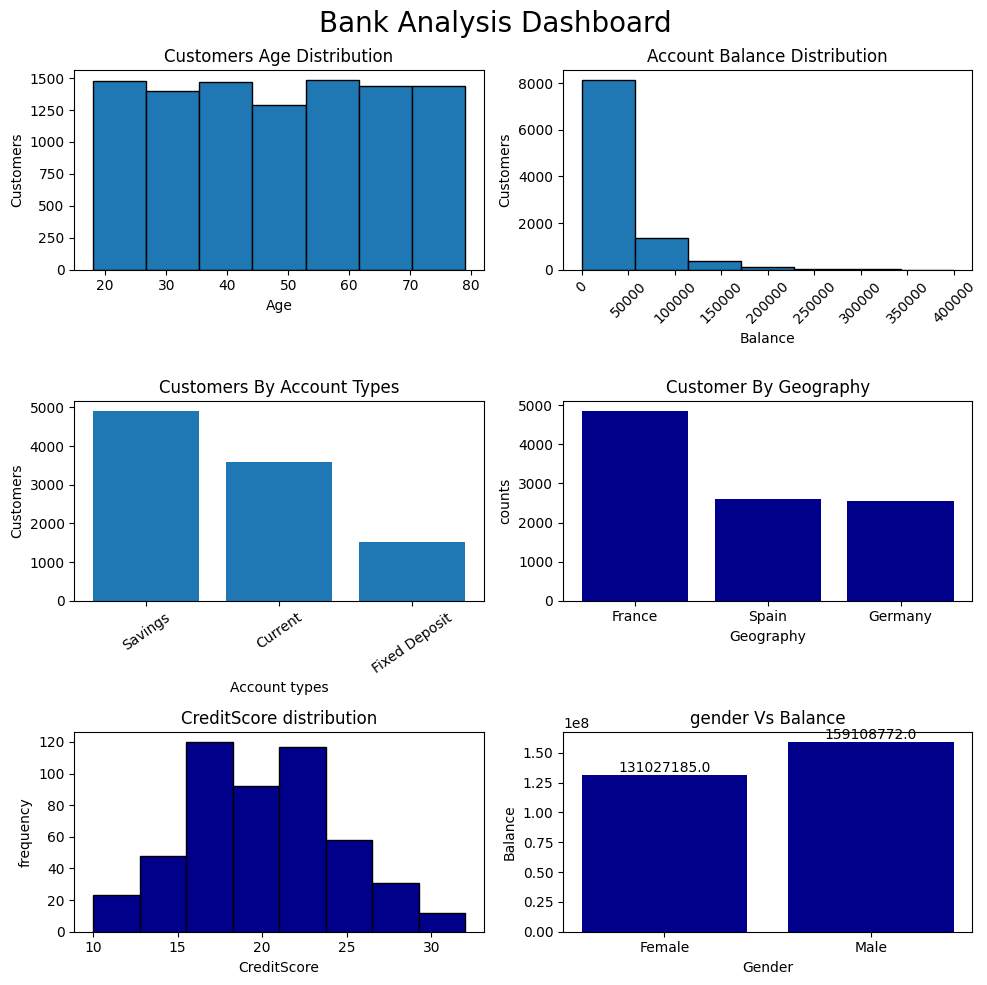

In [32]:
fig,ax = plt.subplots(3,2,figsize=(10,10))
# ist subplot
# age distribution
ax[0,0].hist(df["Age"],bins=7,edgecolor="Black")
ax[0,0].set_title("Customers Age Distribution")
ax[0,0].set_xlabel("Age")
ax[0,0].set_ylabel("Customers")

# 2nd subplot
# Account balance distribution
ax[0,1].hist(df["Balance"],bins=7,edgecolor="black")
ax[0,1].set_title("Account Balance Distribution")
ax[0,1].set_xlabel("Balance")
ax[0,1].set_ylabel("Customers")
ax[0,1].tick_params(axis="x", rotation=45)

# 3rd subplot
# customers by account type
cus_by_acc = df["AccountType"].value_counts()
ax[1,0].bar(cus_by_acc.index,cus_by_acc.values)
ax[1,0].tick_params(axis = "x",rotation=35)
ax[1,0].set_title("Customers By Account Types")
ax[1,0].set_xlabel("Account types")
ax[1,0].set_ylabel("Customers")


# 4th subplot
# customer by city
customer_by_city = df["Geography"].value_counts()
ax[1,1].bar(customer_by_city.index,customer_by_city.values,color="darkblue")
ax[1,1].set_title("Customer By Geography")
ax[1,1].set_xlabel("Geography")
ax[1,1].set_ylabel("counts")

# 5th subplot
# credit score distribution
credit_Score = df["CreditScore"].value_counts()
ax[2,0].hist(credit_Score,bins=8,edgecolor="Black",color="darkblue")
ax[2,0].set_title("CreditScore distribution")
ax[2,0].set_xlabel("CreditScore")
ax[2,0].set_ylabel("frequency")



# 6th subplot
# gender vs balance
gend_vs_bal = df.groupby("Gender")["Balance"].sum()
bar = ax[2,1].bar(gend_vs_bal.index,gend_vs_bal.values,color="Darkblue")
ax[2,1].bar_label(bar , fmt='{:}')
ax[2,1].set_title("gender Vs Balance")
ax[2,1].set_xlabel("Gender")
ax[2,1].set_ylabel("Balance")

plt.suptitle("Bank Analysis Dashboard",fontsize = 20)
plt.tight_layout()
plt.savefig("bank_analysis.png",dpi=300,bbox_inches="tight")
plt.show()

#  Independent t-Test: Comparing the Mean Age of Stayed and Exited Customers

In [9]:

stay_age = df[(df["Exited"] == 0 )]["Age"]
exit_age = df[(df["Exited"] == 1)]["Age"]
t_stat , p_value  = ttest_ind(stay_age,exit_age)
print("T statistics : ",t_stat)
print(" P value : ", p_value)
alpha = 0.05
if p_value < alpha:
    print("Decision: Reject H₀")
    print("Conclusion: Mean age is significantly different.")
else:
    print("Decision: Fail to reject H₀")
    print("Conclusion: No significant difference in mean age.")
    print("Stayed:", len(stay_age))


T statistics :  -8.35810235607107
 P value :  7.22156695293323e-17
Decision: Reject H₀
Conclusion: Mean age is significantly different.


# Do customers who exited the bank have a different average CreditScore compared to customers who stayed?

In [10]:
stay_customer = df[df["Exited"] == 0]["CreditScore"]
exited_customer = df[df["Exited"] == 1]["CreditScore"]

t_stat , p_value = ttest_ind(stay_customer,exited_customer)
print("t test stat  = ",t_stat)
print("P value  = ",p_value)
alpha = 0.05
if p_value < alpha:
    print("we reject the Ho")
    print("conclusion : mean credit score is significantl differ")
else:
    print("we are fail to reject Ho")
    print("conclusion : there is no differnce b/w stayed customer creditscore and exited customer creditscore ")

t test stat  =  -0.2678548984845893
P value  =  0.7888165367695626
we are fail to reject Ho
conclusion : there is no differnce b/w stayed customer creditscore and exited customer creditscore 


# testing wheather geography and exited are independent

In [11]:
from scipy.stats import chi2_contingency
contigency_table = pd.crosstab(df["Geography"],df["Exited"])
print("table that shows the frequency (count) of combinations between two categorical variables:\n",contigency_table)
chi2,dof,p_value,expected = chi2_contingency(contigency_table)
print("chi square test stat : ", chi2)
print("Degree of freedom : ",dof)
print("p_value : ",p_value)
print("expected frequency : \n",expected)
alpha = 0.05
if p_value < alpha:
    print("Decision : we reject the  Ho")
    print("Conclusion : there are statistically association b/w geography and exited customer ")
else :
    print("Decision : we are fail to reject the Ho")
    print("conclusion : there are no association b/w geogrphy and exited customer ")

table that shows the frequency (count) of combinations between two categorical variables:
 Exited        0     1
Geography            
France     3776  1082
Germany    1976   575
Spain      2024   567
chi square test stat :  0.32636618542911733
Degree of freedom :  0.8494356486971674
p_value :  2
expected frequency : 
 [[3777.5808 1080.4192]
 [1983.6576  567.3424]
 [2014.7616  576.2384]]
Decision : we are fail to reject the Ho
conclusion : there are no association b/w geogrphy and exited customer 


# Account type vs churned 

In [17]:
from scipy.stats import chi2_contingency
contigency_table = pd.crosstab(df["AccountType"],df["Exited"])
print(contigency_table)

chi2,dof,p_value,expectd = chi2_contingency(contigency_table)
print("\n\nchi square test sata = ", chi2.round(2))
print("degree of freedom  = ",dof.round(2))
print("p value  = ",p_value)
print("expected frequency  = ",expectd.round(2))

alpha = 0.05
if p_value < alpha :
    print("Decision : Reject the Ho ")
    print("Conclusion : there is statistically association b/w account type and churn")
else:
    print("Decision : We are fail to Reject the ho")
    print("there is no statisticall association b/e account type and churn")

Exited            0     1
AccountType              
Current        2761   822
Fixed Deposit  1164   344
Savings        3851  1058


chi square test sata =  2.65
degree of freedom  =  0.27
p value  =  2
expected frequency  =  [[2786.14  796.86]
 [1172.62  335.38]
 [3817.24 1091.76]]
Decision : We are fail to Reject the ho
there is no statisticall association b/e account type and churn


# Anova test
# Balance across countries

In [29]:
# Null Hypothesis (H₀):
# Mean Balance of France = Mean Balance of Germany = Mean Balance of Spain
# H₀: μFrance = μGermany = μSpain
# Alternative Hypothesis (H₁):
# At least one country's mean Balance is different
from scipy.stats import f_oneway
france_balance = df[df["Geography"] == "France"]["Balance"].dropna()
germany_balance = df[df["Geography"] == "Germany"]["Balance"].dropna()
spain_balance = df[df["Geography"] == "Spain"]["Balance"].dropna()
f_stat,p_value = f_oneway(france_balance,germany_balance,spain_balance)
print("F test stat = ",f_stat.round(3))
print("P value =",p_value.round(3))
alpha = 0.05
if p_value < alpha :
     print("Decison : reject the null hypothesis") 
     print("Conclusion : the mean balance is significantly different across the countries .")  
else :
     print("Decision : we are fail to reject the null hypothesis")  
     print("Conclusion : the mean balance are same across  the countries .")

F test stat =  7.02
P value = 0.001
Decison : reject the null hypothesis
Conclusion : the mean balance is significantly different across the countries .


# Insights
*  The Average Age of customers :  48
*  The Average Balance of the customer :  29013
* Churn rate of the France customers are high.
* Large number of customers have Savings account.
* Savings account have high churn rate .
* mostly customers do not complain but leave the bank.